In [1]:
# imports
suppressPackageStartupMessages({
    library(data.table)
    library(Matrix)
    library(Seurat)
    library(ggplot2)
    library(dplyr)
    library(ggthemes)
    library(tidyr)
    library(tibble)
    source('../_common/typing_utils.r')
})

In [2]:
samples = 'EDP1-EDP2-ARB'

In [3]:
plot_dir = paste0("diagnostic_plots/", samples, "/3.assign_clusters_to_lineages")
dir.create(plot_dir, showWarnings = FALSE, recursive = TRUE)

# Examine overlap of marker genes between clusters and AMPp2 cell types

In [4]:
markers_xen <- read.csv(paste0("out_analysis/", samples, "/xenium_cluster_markers.csv"))
markers_sc <- read.csv(paste0("out_analysis/", samples, "/sc_cluster_markers.csv"))

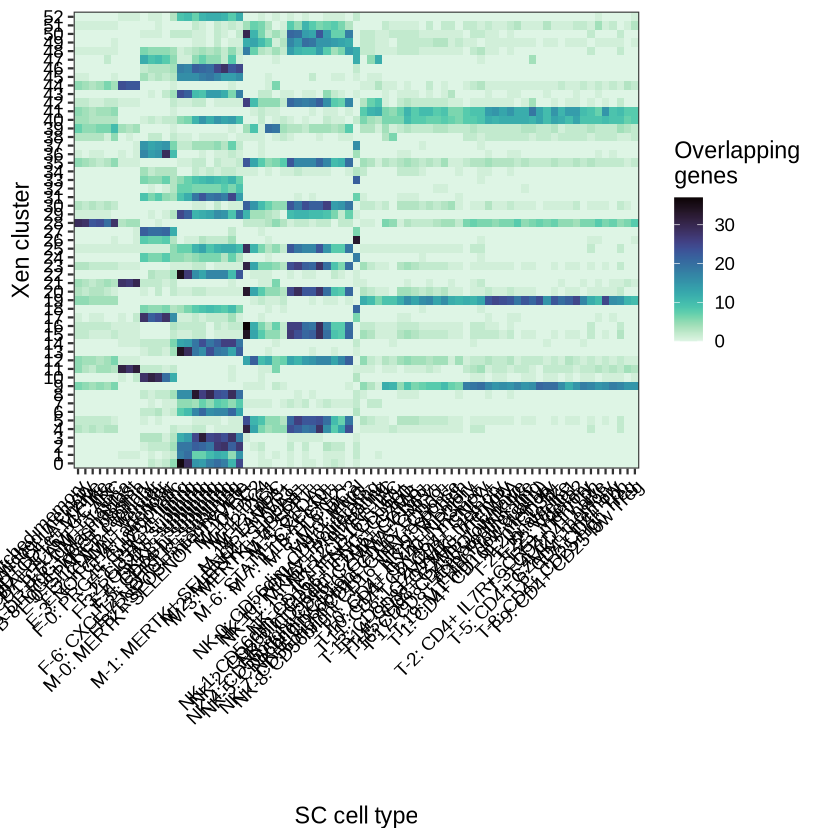

In [5]:
# 1. Top 50 marker genes per cluster
top50_xen <- markers_xen %>%
    group_by(group) %>%
    arrange(desc(logFC)) %>%
    slice_head(n = 50) %>%
    ungroup()

top50_sc <- markers_sc %>%
    group_by(group) %>%
    arrange(desc(logFC)) %>%
    slice_head(n = 50) %>%
    ungroup()

# 2. Compute pairwise intersection sizes
xen_clusters <- unique(top50_xen$group)
sc_celltypes <- unique(top50_sc$group)

overlap_mat <- outer(
    xen_clusters, sc_celltypes,
    FUN = Vectorize(function(xc, sc_ct) {
        genes_xen <- top50_xen$feature[top50_xen$group == xc]
        genes_sc  <- top50_sc$feature[top50_sc$group == sc_ct]
        length(intersect(genes_xen, genes_sc))
    })
)
rownames(overlap_mat) <- xen_clusters
colnames(overlap_mat) <- sc_celltypes

# 3. Heatmap
overlap_long <- as.data.frame(overlap_mat) %>%
    tibble::rownames_to_column("xen_cluster") %>%
    tidyr::pivot_longer(-xen_cluster, names_to = "sc_cell_type", values_to = "overlap") %>%
    mutate(xen_cluster  = factor(xen_cluster,  levels = xen_clusters),
           sc_cell_type = factor(sc_cell_type, levels = sc_celltypes))

p <- ggplot(overlap_long, aes(x = sc_cell_type, y = xen_cluster, fill = overlap)) +
    geom_tile() +
    scale_fill_gradientn(colours = viridisLite::mako(100, direction = -1),
                         name = "Overlapping\ngenes") +
    theme_bw(base_size = 14) +
    theme(axis.text.x  = element_text(angle = 45, hjust = 1, color = "black"),
          axis.text.y  = element_text(color = "black"),
          panel.grid   = element_blank()) +
    xlab("SC cell type") + ylab("Xen cluster")

ggsave(paste0(plot_dir, "/heatmap_xen_cluster_vs_sc_celltype_overlap.png"),
       p, width = 20, height = 14)
p

# Examine specific groups that didn't map to anything

In [186]:
top50_xen %>% filter(group == "22") %>% slice_head(n = 10)
print("Adipocytes")

feature,group,avgExpr,logFC,statistic,auc,pval,padj,pct_in,pct_out
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PLIN4,22,1.6298420,1.6243257,930680796,0.9282899,0,0,85.85799,0.9055357
PLIN1,22,1.3227866,1.3203330,904112605,0.9017900,0,0,80.47337,0.3789360
ADIPOQ,22,1.1915983,1.1898718,876757486,0.8745051,0,0,75.00000,0.2413863
PNPLA2,22,1.0069603,0.9421317,832178963,0.8300411,0,0,70.68047,12.4115029
CIDEC,22,0.8496452,0.8475140,823514518,0.8213989,0,0,64.46746,0.3681478
LPL,22,0.7415931,0.7339958,791025878,0.7889937,0,0,58.52071,1.2628953
AOC3,22,0.6829548,0.6493648,769354568,0.7673781,0,0,56.59763,4.8644731
CD36,22,0.6343578,0.6087629,761450846,0.7594947,0,0,54.43787,3.7674466
AQP7,22,0.4474757,0.4413229,677549734,0.6758091,0,0,35.97633,1.1243342


[1] "Adipocytes"


In [187]:
top50_xen %>% filter(group == "24") %>% slice_head(n = 10)
print("Neuronal and glial")

feature,group,avgExpr,logFC,statistic,auc,pval,padj,pct_in,pct_out
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SOX2-OT,24,1.0676810,0.9910067,358510041,0.7651722,0.000000e+00,0.000000e+00,58.53503,10.48855678
SOST,24,0.5366062,0.4830131,317224809,0.6770567,0.000000e+00,0.000000e+00,41.21019,8.73772744
SNHG15,24,0.4159675,0.3553814,289622009,0.6181437,8.202538e-214,1.608959e-211,30.95541,9.78990048
MPZ,24,0.2307875,0.2215344,269203000,0.5745631,0.000000e+00,0.000000e+00,16.56051,1.90999564
DUX4,24,0.2215829,0.2153994,274316511,0.5854770,0.000000e+00,0.000000e+00,17.96178,1.00894682
CDC27,24,0.2135912,0.1764334,260173388,0.5552911,2.766524e-63,1.763659e-61,17.26115,7.23888349
DST,24,0.3275551,0.1707439,253542355,0.5411384,6.923507e-14,3.936442e-13,27.77070,24.23918507
ALG11,24,0.1752720,0.1505440,259585918,0.5540373,2.970010e-90,3.222777e-88,14.90446,4.66005428
SOX10,24,0.1482615,0.1479548,267147861,0.5701768,0.000000e+00,0.000000e+00,14.07643,0.04456657


[1] "Neuronal and glial"


In [188]:
top50_xen %>% filter(group == "25") %>% slice_head(n = 10)
print("Mast")

feature,group,avgExpr,logFC,statistic,auc,pval,padj,pct_in,pct_out
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HDC,25,0.8318920,0.8314324,326187421,0.8072560,0.000000e+00,0.000000e+00,61.49298,0.07266103
GATA2,25,0.8354863,0.8292877,342683459,0.8480807,0.000000e+00,0.000000e+00,70.14043,1.15052219
KIT,25,0.8052810,0.8034530,339085064,0.8391753,0.000000e+00,0.000000e+00,67.99704,0.33082536
SLC18A2,25,0.7984067,0.7979286,342165527,0.8467989,0.000000e+00,0.000000e+00,69.40133,0.08069728
CTSG,25,0.7838559,0.7827953,312330149,0.7729617,0.000000e+00,0.000000e+00,54.69327,0.16608236
MS4A2,25,0.6032102,0.6027550,323331363,0.8001877,0.000000e+00,0.000000e+00,60.08869,0.08069728
HPGD,25,0.5123940,0.5091390,305405585,0.7558246,0.000000e+00,0.000000e+00,51.58906,0.63486323
IL1RL1,25,0.4858578,0.4855026,302292052,0.7481192,0.000000e+00,0.000000e+00,49.66741,0.05993698
CD44,25,0.7135313,0.4319298,281223273,0.6959777,1.136895e-179,9.827397e-178,65.77975,37.71978289


[1] "Mast"


In [189]:
top50_xen %>% filter(group == "29") %>% slice_head(n = 10)
print("Osteoclast")

feature,group,avgExpr,logFC,statistic,auc,pval,padj,pct_in,pct_out
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MMP9,29,2.3754812,2.3646202,1199539,0.9996292,3.221696e-69,5.476884e-66,100,1.307351
SPP1,29,2.2037104,2.0973978,1030074,0.8584062,1.888464e-09,5.350649e-07,75,6.053747
ANPEP,29,1.2457543,1.1281105,1157271,0.9644052,2.059098e-06,3.500466e-04,100,18.530914
CTSK,29,1.1965984,1.1061142,1181790,0.9848377,3.624149e-08,9.241579e-06,100,14.357858
NFATC1,29,1.0614294,1.0316713,1194426,0.9953683,6.101958e-17,3.889998e-14,100,5.960413
CSF1R,29,0.9555437,0.8838696,1170890,0.9757543,1.105450e-09,3.758529e-07,100,10.896812
ACP5,29,0.8764866,0.8582823,1040329,0.8669520,2.879809e-15,1.468703e-12,75,3.581381
INPPL1,29,0.8630197,0.7823846,1165089,0.9709204,1.443380e-07,3.200538e-05,100,14.948533
HSPA8,29,0.9715266,0.7238493,1099859,0.9165613,7.363922e-04,5.365143e-02,100,35.440139


[1] "Osteoclast"


# Final assignments

In [190]:
cluster_annotations <- c(
    "0"  = "Stromal",
    "1"  = "Stromal",
    "2"  = "Stromal",
    "3"  = "Myeloid",
    "4"  = "Myeloid",
    "5"  = "Mural",
    "6"  = "Myeloid",
    "7"  = "B/plasma",
    "8"  = "T/NK",
    "9"  = "Endothelial",
    "10" = "Endothelial",
    "11" = "Stromal",
    "12" = "Stromal",
    "13" = "Myeloid",
    "14" = "Stromal", #probably with some endothelial contamination
    "15" = "Stromal",
    "16" = "T/NK",
    "17" = "Myeloid+Stromal",
    "18" = "Proliferating",
    "19" = "Mural",
    "20" = "B/plasma",
    "21" = "Myeloid+Stromal",
    "22" = "Adipocyte",
    "23" = "Myeloid", # with contamination NOS
    "24" = "Neuronal/glial",
    "25" = "Mast",
    "26" = "Myeloid",
    "27" = "Myeloid+B/plasma",
    "28" = "Myeloid",
    "29" = "Osteoclast"
)

# Apply lineage assignments and qc out cells that didn't cluster well (hopefully to remove some spatial doublets)

In [6]:
xen <- readRDS(paste0("out_rds/", samples, "/allcells_qc_harmumapclust.rds"))

In [161]:
xen@meta.data$lineage <- cluster_annotations[as.character(xen@meta.data$seurat_clusters)]

In [162]:
library(Matrix)
graph <- xen[["humap_fgraph"]]
lineage <- factor(xen@meta.data$lineage)
lineage_levels <- levels(lineage)

# One-hot encode lineage: cells x lineage_levels sparse matrix
one_hot <- sparse.model.matrix(~ lineage - 1, 
                                data = data.frame(lineage = lineage))
colnames(one_hot) <- lineage_levels

# Matrix multiply: (cells x cells) %*% (cells x lineage) = (cells x lineage)
# Each entry [i, j] = number of neighbors of cell i with lineage j
neighbor_lineage_counts <- graph %*% one_hot
neighbor_lineage_counts <- as.data.frame(as.matrix(neighbor_lineage_counts))

In [163]:
# count how many neighbhors have the same lineage as each cell
same_lineage <- neighbor_lineage_counts[
    cbind(seq_len(nrow(neighbor_lineage_counts)),
          match(xen@meta.data$lineage, colnames(neighbor_lineage_counts)))
]

matches <- data.frame(
    lineage      = xen@meta.data$lineage,
    same_lineage = same_lineage,
    total        = rowSums(neighbor_lineage_counts)
)

In [164]:
# Summarize which clusters had many cells with fewer than 80% agreement with nearest neighbors
matches$seurat_clusters <- xen@meta.data$seurat_clusters

matches %>%
    group_by(seurat_clusters) %>%
    summarise(
        n_cells     = n(),
        n_high      = sum(same_lineage / total > 0.8, na.rm = TRUE),
        pct_high    = round(100 * n_high / n_cells, 1)
    ) %>%
    arrange(as.numeric(as.character(seurat_clusters))) %>%
    print(n = Inf)

# A tibble: 30 × 4
   seurat_clusters n_cells n_high pct_high
   <fct>             <int>  <int>    <dbl>
 1 0                448284 439489     98  
 2 1                429025 412995     96.3
 3 2                379799 372457     98.1
 4 3                348743 326237     93.5
 5 4                341041 331970     97.3
 6 5                317202 296251     93.4
 7 6                310166 301272     97.1
 8 7                265192 252454     95.2
 9 8                238084 216424     90.9
10 9                236576 229347     96.9
11 10               232921 228819     98.2
12 11               220650 194458     88.1
13 12               218889 211991     96.8
14 13               201573 190784     94.6
15 14               140370 129979     92.6
16 15               103366 102085     98.8
17 16               100004  98254     98.3
18 17                91919  46160     50.2
19 18                89716  73748     82.2
20 19                88488  86252     97.5
21 20                87091  79235  

In [200]:
# how many cells overall didn't pass this QC threshold
n_passed <- sum(matches$same_lineage / matches$total > 0.8)
n_passed
nrow(matches)
n_passed / nrow(matches)

[1] 4816650

[1] 5150888

[1] 0.9351106

In [174]:
# annotate which cells were low quality
xen@meta.data$lineage_qc <- ifelse(
    matches$same_lineage / matches$total > 0.8,
    xen@meta.data$lineage,
    "Low quality"
)

In [176]:
# Make faceted plot of cells before and after qc
ggsave(paste0(plot_dir, "/umap_facet_by_lineageandfinecluster.png"),
       DimPlot(xen, group.by = "seurat_clusters", reduction = "humap", alpha = 0.1,
               split.by = "lineage", raster = TRUE, ncol = 5),
       width = 30, height = 20)

xen@meta.data$lineage_qc <- factor(xen@meta.data$lineage_qc,
                                    levels = c(sort(setdiff(unique(xen@meta.data$lineage_qc), 
                                                            "Low quality")), 
                                               "Low quality"))

ggsave(paste0(plot_dir, "/umap_facet_by_lineageqcandfinecluster.png"),
       DimPlot(xen, group.by = "seurat_clusters", reduction = "humap", alpha = 0.1,
               split.by = "lineage_qc", raster = TRUE, ncol = 5),
       width = 30, height = 20)

In [205]:
# make lineage UMAP plot
p <- DimPlot(xen, group.by = "lineage_qc", reduction = "humap", raster = TRUE, raster.dpi = c(2048, 2048), alpha=0.3) +
           scale_color_tableau("Tableau 20")

ggsave(paste0(plot_dir, "/xenium_lineageqc_umap.png"),
       p, width=25, height=20, dpi=400)

In [213]:
library(scattermore)

make_lineage_umap <- function(umap_coords, filename) {
    p <- ggplot(umap_coords, aes(x = HUMAP_1, y = HUMAP_2, color = lineage)) +
        geom_scattermore(data = filter(umap_coords, lineage == "Low quality"),
                         color = "gray90", alpha = 0.05, pointsize = 1) +
        geom_scattermore(data = filter(umap_coords, lineage != "Low quality"),
                         aes(color = lineage), alpha = 0.3, pointsize = 1) +
        scale_color_tableau("Tableau 20") +
        theme_bw(base_size = 14) +
        guides(color = guide_legend(override.aes = list(size = 3, alpha = 1))) +
        xlab("HUMAP 1") + ylab("HUMAP 2")
    ggsave(filename, p, width = 25, height = 20, dpi = 150)
}

umap_coords <- as.data.frame(xen[["humap"]]@cell.embeddings)

umap_coords$lineage <- xen@meta.data$lineage_qc
make_lineage_umap(umap_coords, paste0(plot_dir, "/xenium_lineageqc_umap.png"))

umap_coords$lineage <- xen@meta.data$lineage
make_lineage_umap(umap_coords, paste0(plot_dir, "/xenium_lineage_umap.png"))

# Check against known marker genes

In [229]:
m <- list(
    t = c("CD3E", "CD8A", "CD4", "IL7R",
                "NKG7", "NCAM1"), #NK
    b.plasma = c("MS4A1", "CD19", "CD79A", #B
                "PRDM1", "MZB1", "XBP1"), #plasma
    myeloid = c("CD14", "CD68",
                "FCGR3A", "LYVE1", "C1QA", "MARCO"),
               # "CLEC10A",#dendritic)
    mast = c("HDC", "KIT"), #mast
    endothelial = c("PECAM1", "VWF", "CDH5", "FLT1"),
    stromal = c("PRG4", "CD55", #lining
                "COL6A1", "CXCL12", "PDPN", "THY1", #sublining
                "PDGFRB","ACTA2"), #pericytes/mural
    adipocytes = c("ADIPOQ", "PLIN1", "PLIN4"), #adipocytes
    proliferating = c("MKI67", "TOP2A"), #prolif
    muscles = c("MYOD1","CD82")
               )

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.5 GiB”


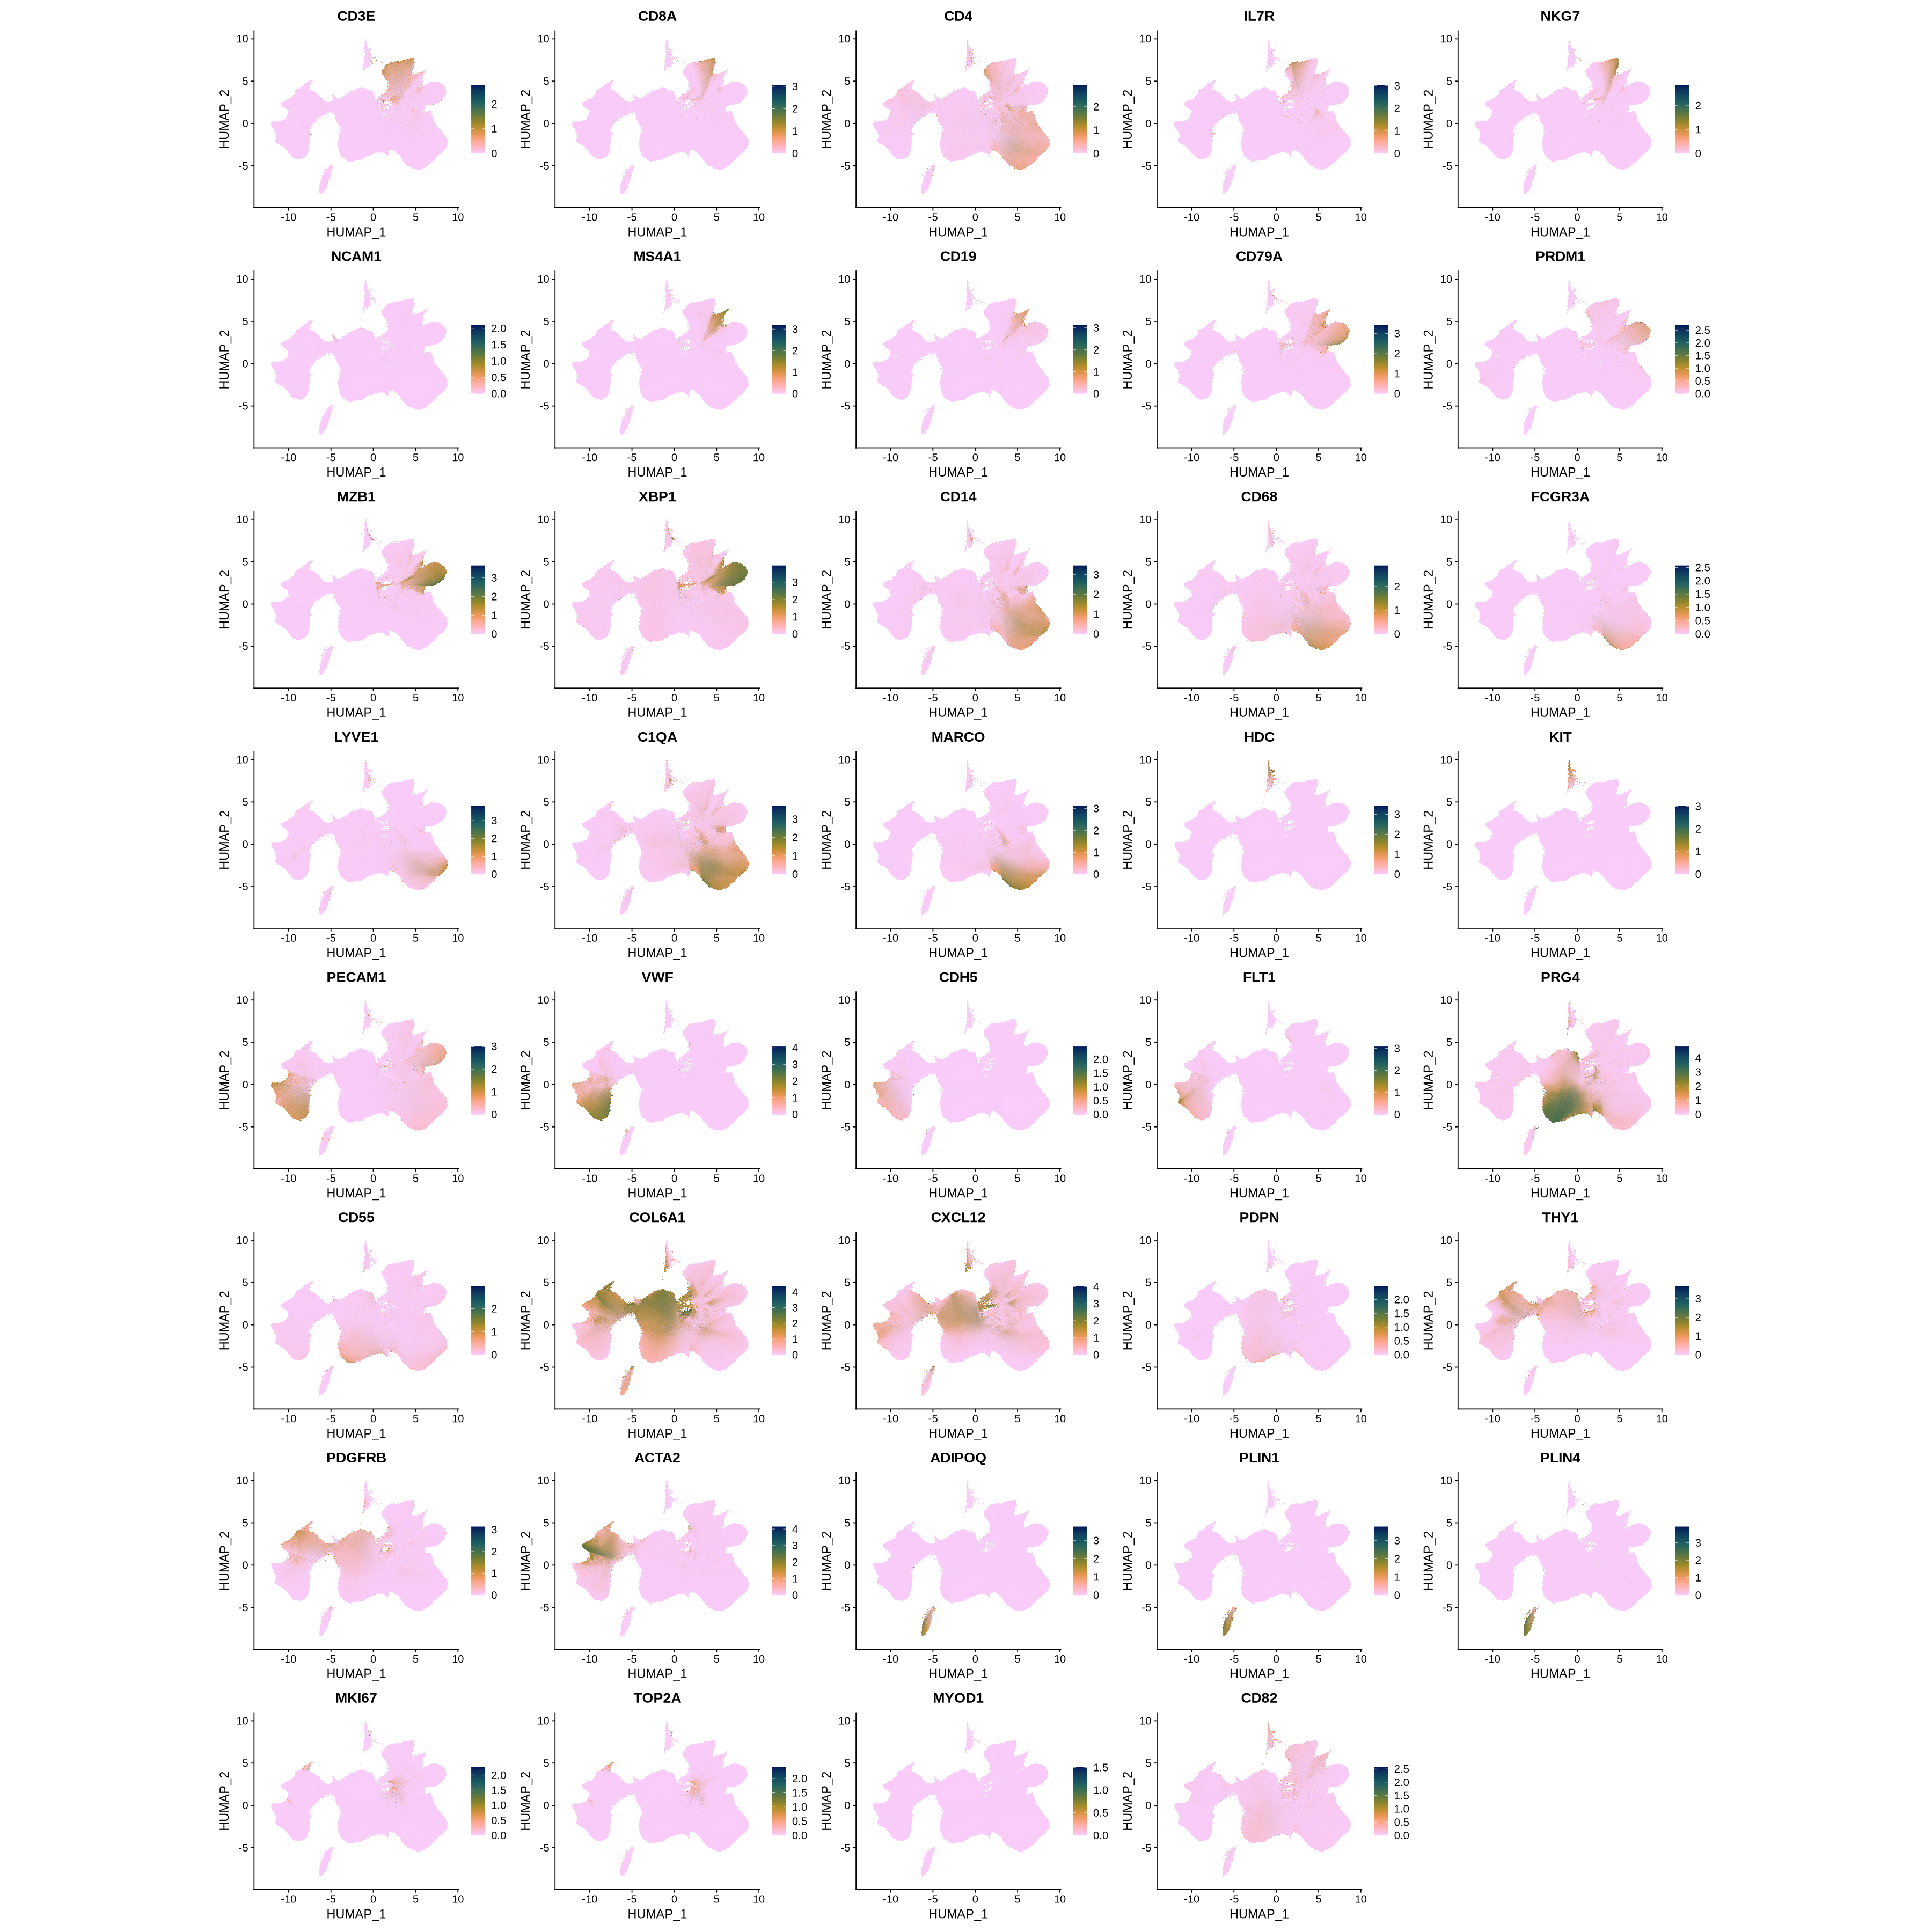

In [231]:
fig.size(30,30)
suppressMessages(FeaturePlot(xen, features = unlist(m), ncol = 5, raster=T, order = T) & coord_fixed() &
                 scico::scale_color_scico(palette = 'batlow', direction = -1))

In [ ]:
# summarize marker gene expression across clusters
exp_mat <- FetchData(xen, vars = unlist(m), layer = "data")
meta <- seu_qc@meta.data %>% 
  select(seurat_clusters)
meta <- bind_cols(meta, exp_mat)

meta <- pivot_longer(meta, -seurat_clusters, names_to="Gene", values_to="Expression")
meta <- meta %>% left_join(data.frame(unlist(m)) %>% tibble::rownames_to_column("lineage") %>% mutate(lineage = gsub("[[:digit:]]", "", lineage)), by = join_by(Gene == unlist.m.))

meta_summary <- meta %>%
  group_by(seurat_clusters, Gene, lineage) %>%
  summarise(Avg = mean(Expression),
            Pct = sum(Expression > 0) / length(Expression) * 100)

dot_plot <- ggplot(meta_summary, aes(x=Gene, y=seurat_clusters)) +
  geom_point(aes(size = Pct, fill = Avg), shape=21, stroke = NA) +
  scale_size("% detected", range = c(0,6)) +
  scale_fill_gradientn(colours = viridisLite::mako(100, direction = -1),
                       guide = guide_colorbar(ticks.colour = "black",
                                              frame.colour = "black"),
                       name = "Average\nexpression") +
  ylab("Cluster") + xlab("") +
  facet_grid(. ~ lineage, scales = "free_x", space = "free_x") +
  theme_bw(base_size = 18) +
  theme(axis.text.x = element_text(size=12, angle=45, hjust=1, color="black"),
        axis.text.y = element_text(size=12, color="black"),
        axis.title = element_text(size=14),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank())

fig.size(5, 22)
dot_plot

# Assess distribution by cohort

In [224]:
# annotate arbitrate into pre- and post-tx
xen@meta.data <- xen@meta.data %>%
    mutate(cohort = case_when(
        cohort == "ARBITRATE" & grepl("pre",  donor_visit, ignore.case = TRUE) ~ "ARBITRATE-PRE",
        cohort == "ARBITRATE" & grepl("post", donor_visit, ignore.case = TRUE) ~ "ARBITRATE-POST",
        TRUE ~ cohort
    ))

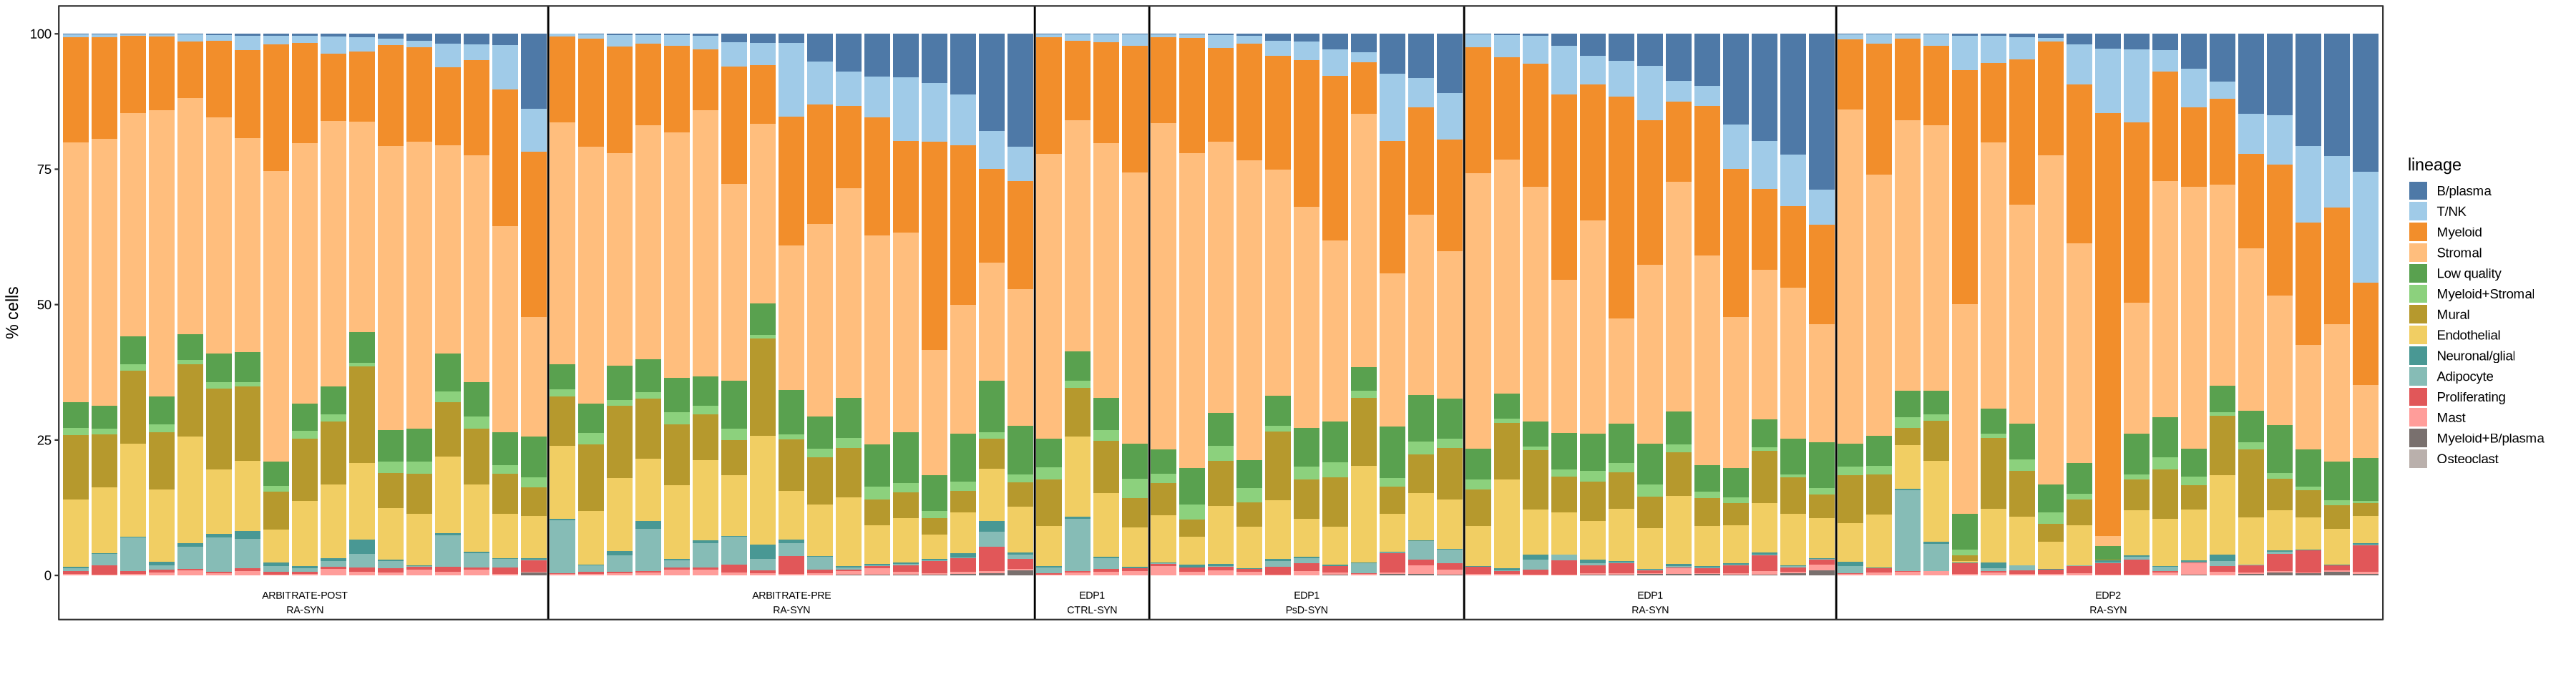

In [228]:
meta <- xen@meta.data %>%
    group_by(donor_visit, cohort, subset, lineage) %>%
    summarise(n = n(), .groups = "drop") %>%
    group_by(donor_visit) %>%
    mutate(pct = n / sum(n) * 100) %>%
    ungroup()

# compute B/plasma proportion per donor_visit for sorting
bplasma_pct <- meta %>%
    filter(lineage == "B/plasma") %>%
    select(donor_visit, bplasma_pct = pct)

donor_order <- meta %>%
    distinct(donor_visit, cohort, subset) %>%
    left_join(bplasma_pct, by = "donor_visit") %>%
    mutate(bplasma_pct = replace_na(bplasma_pct, 0)) %>%
    arrange(cohort, subset, bplasma_pct) %>%
    pull(donor_visit)

meta$donor_visit <- factor(meta$donor_visit, levels = donor_order)

# compute positions of vertical lines and subset labels
donor_info <- meta %>%
    distinct(donor_visit, cohort, subset) %>%
    arrange(cohort, subset) %>%
    mutate(x = as.integer(factor(donor_visit, levels = donor_order)))

# vertical line positions: between last donor of one subset and first of next
vlines <- donor_info %>%
    group_by(cohort, subset) %>%
    summarise(xend = max(x), .groups = "drop") %>%
    filter(xend < max(donor_info$x)) %>%
    pull(xend) + 0.5

# subset label x positions: midpoint of each subset's bars
subset_labels <- donor_info %>%
    group_by(cohort, subset) %>%
    summarise(x_mid = mean(x), .groups = "drop")

lineage_order <- c("B/plasma", "T/NK", "Myeloid", "Stromal",
                   setdiff(unique(xen@meta.data$lineage), 
                           c("B/plasma", "T/NK", "Myeloid", "Stromal")))

meta$lineage <- factor(meta$lineage, levels = lineage_order)

p <- ggplot(meta, aes(x = donor_visit, y = pct, fill = lineage)) +
    geom_col() +
    geom_vline(xintercept = vlines, color = "black", linewidth = 0.8) +
    scale_fill_tableau("Tableau 20") +
    scale_x_discrete(breaks = subset_labels$x_mid,
                     labels = NULL) +
    annotate("text",
             x     = subset_labels$x_mid,
             y     = -3,
             label = paste0(subset_labels$cohort, "\n", subset_labels$subset),
             size  = 3, hjust = 0.5, vjust = 1) +
    coord_cartesian(clip = "off") +
    theme_bw(base_size = 14) +
    theme(axis.text.x    = element_blank(),
          axis.ticks.x   = element_blank(),
          axis.text.y    = element_text(color = "black"),
          panel.grid     = element_blank(),
          plot.margin    = margin(t = 5, r = 5, b = 40, l = 5)) +
    xlab("") + ylab("% cells")

p

# Save

In [214]:
# 1. Remove lineage and rename lineage_qc to lineage
xen@meta.data$raw_lineage <- xen@meta.data$lineage
xen@meta.data$lineage <- xen@meta.data$lineage_qc
xen@meta.data$lineage_qc <- NULL

# 2. Save metadata, harmony, and humap
saveRDS(xen@meta.data,
        paste0("out_rds/", samples, "/allcells_qc_harmumapclust_lineage[metadata].rds"))
saveRDS(xen[["harmony"]]@cell.embeddings,
        paste0("out_rds/", samples, "/allcells_qc_harmumapclust_lineage[harmony].rds"))
saveRDS(xen[["humap"]]@cell.embeddings,
        paste0("out_rds/", samples, "/allcells_qc_harmumapclust_lineage[humap].rds"))

# 3. Save xen
message(Sys.time(), " | Saving xen with lineage...")
saveRDS(xen, paste0("out_rds/", samples, "/allcells_qc_harmumapclust_lineage.rds"))

# 4. Discard NNG
xen[["humap_fgraph"]] <- NULL

# 5. Make lineages directory
dir.create(paste0("out_rds/", samples, "/lineages"), showWarnings = FALSE, recursive = TRUE)

# 6. Save per-lineage subsets
for (lin in unique(xen@meta.data$lineage)) {
    lin_name <- gsub("/", "_", lin)
    message(Sys.time(), " | Saving lineage: ", lin_name)
    lin_cells <- colnames(xen)[xen@meta.data$lineage == lin]
    lin_seu   <- subset(xen, cells = lin_cells)
    saveRDS(lin_seu, paste0("out_rds/", samples, "/lineages/", lin_name, ".rds"))
    rm(lin_seu)
    gc()
}

message(Sys.time(), " | Done.")

2026-05-30 17:05:28.333092 | Saving xen with lineage...

2026-05-30 17:30:51.949932 | Saving lineage: Stromal

2026-05-30 17:41:21.978204 | Saving lineage: Myeloid

2026-05-30 17:48:29.746315 | Saving lineage: Low quality

2026-05-30 17:51:12.278518 | Saving lineage: Myeloid+Stromal

2026-05-30 17:52:52.009206 | Saving lineage: Mural

2026-05-30 17:55:43.538161 | Saving lineage: Endothelial

2026-05-30 17:59:16.200104 | Saving lineage: Neuronal_glial

2026-05-30 18:00:25.638311 | Saving lineage: Adipocyte

2026-05-30 18:01:43.977182 | Saving lineage: Proliferating

2026-05-30 18:03:19.91034 | Saving lineage: T_NK

2026-05-30 18:05:59.050358 | Saving lineage: Mast

2026-05-30 18:07:09.343039 | Saving lineage: B_plasma

2026-05-30 18:09:59.918583 | Saving lineage: Myeloid+B_plasma

2026-05-30 18:11:09.116097 | Saving lineage: Osteoclast

2026-05-30 18:12:16.106385 | Done.



# Unused

In [88]:
humap    <- readRDS(paste0("out_rds/", samples, "/allcells_qc_harmumapclust[humap].rds"))
metadata <- readRDS(paste0("out_rds/", samples, "/allcells_qc_harmumapclust[metadata].rds"))

counts_dummy <- matrix(0, nrow = 2, ncol = nrow(metadata),
                       dimnames = list(c("placeholder1", "placeholder2"), rownames(metadata)))
xen <- CreateSeuratObject(
    counts    = counts_dummy,
    meta.data = metadata
)
xen[["humap"]] <- CreateDimReducObject(
    embeddings = humap,
    key        = "humap_",
    assay      = "RNA"
)

Warning message:
“Data is of class matrix. Coercing to dgCMatrix.”


In [108]:
xen@meta.data$lineage <- cluster_annotations[as.character(xen@meta.data$seurat_clusters)]

In [110]:
p <- DimPlot(xen, group.by = "lineage", reduction = "humap", raster = TRUE) +
           scale_color_tableau("Tableau 20")

ggsave(paste0("diagnostic_plots/", samples, "/xenium_lineage_umap.png"),
       p, width=25, height=20)

In [114]:
ggsave(paste0("diagnostic_plots/", samples, "/umap_facet_by_lineage.png"),
       DimPlot(xen, group.by = "lineage", reduction = "humap",
               split.by = "lineage", raster = TRUE, ncol = 5),
       width = 30, height = 20)

In [120]:
ggsave(paste0("diagnostic_plots/", samples, "/umap_facet_by_lineageandfinecluster.png"),
       DimPlot(xen, group.by = "seurat_clusters", reduction = "humap", alpha=0.1,
               split.by = "lineage", raster = TRUE, ncol = 5),
       width = 30, height = 20)